In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

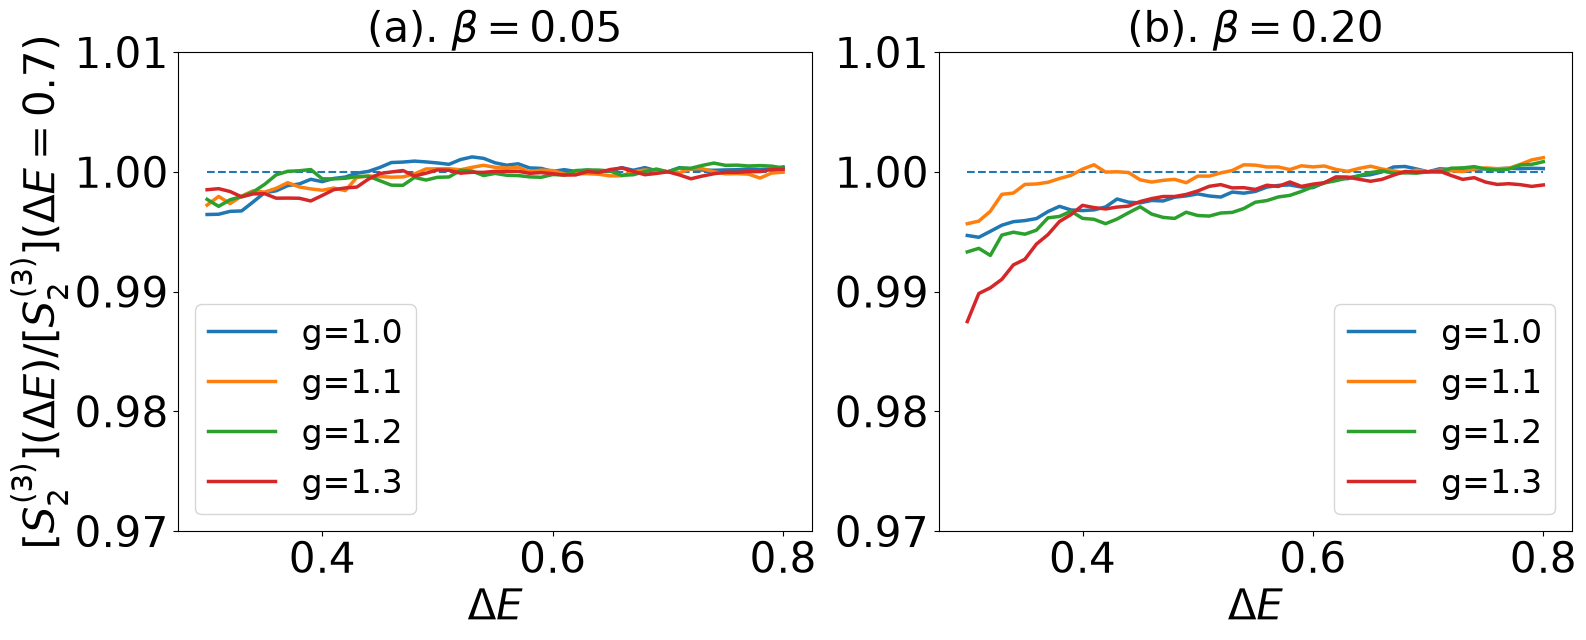

In [2]:
h2_list = [1.00, 1.10, 1.20, 1.30]
beta = [0.05, 0.2]

# ── Font sizes ────────────────────────────────────────────────────────────────
LABEL_FONTSIZE  = 30
TICK_FONTSIZE   = 30
LEGEND_FONTSIZE = 24
TITLE_FONTSIZE  = 30

fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))

for ax, b, letter in zip(axes, beta, "ab"):
    for h2 in h2_list:
        file_name = "data/L_15_multi_analytical_beta_{:.2f}_h2_{:.2f}.csv".format(b, h2)
        data_multi_analytical = pd.read_csv(file_name, header=None)
        delta_list = data_multi_analytical[0]
        default = data_multi_analytical[1][40]
        multi_analytical = data_multi_analytical[1] / default
        ax.errorbar(delta_list, multi_analytical, linewidth = 2.5, label="g=" + str(h2))

    ax.hlines(y=1, xmin=0.3, xmax=0.8, linestyles="--")
    ax.set_ylim(0.97, 1.01)
    ax.set_title("({}). ".format(letter) + r"$\beta = {:.2f}$".format(b), fontsize=TITLE_FONTSIZE)
    ax.set_xlabel(r"$\Delta E$", fontsize=LABEL_FONTSIZE)
    ax.tick_params(axis="both", labelsize=TICK_FONTSIZE)
    ax.legend(fontsize=LEGEND_FONTSIZE)

axes[0].set_ylabel(
    r"$[S_2^{(3)}](\Delta E)/[S_2^{(3)}](\Delta E=0.7)$",
    fontsize=LABEL_FONTSIZE,
)

fig.tight_layout()
fig.savefig("fig_10_new.pdf", dpi=300, bbox_inches="tight")
plt.show()